# 02 · From vectors to vision: a convolutional network on MNIST

Our previous model — a Multi-Layer Perceptron — treated each image as a flat vector of 784 numbers.

But... does that make sense?

When humans look at a digit, we don't scan each pixel one-by-one.  
We recognize *shapes*, *edges*, *patterns*.  
A "9" looks like a loop with a stick. A "3" has two bumps.  
And those patterns live in the **spatial structure** of the image.

A Convolutional Neural Network (CNN) captures that spatial information.  
It doesn't flatten. It slides filters across the image, detecting local patterns like edges, curves, and corners.

Let’s now build a CNN — a model that *sees* like a machine, but learns like us.

**Run it:** from the repository root, `uv sync --group notebooks && uv run --group notebooks jupyter lab`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

tf.keras.utils.set_random_seed(0)

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

The data are, again, arrays of pixel intensities. This time we will **not** flatten them: the network needs
to know which pixels are neighbours.

First, as before, rescale pixel values to the [0, 1] range:

In [3]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Add a channel dimension

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

Each image is now a 28×28 plate with a depth of 1: one grayscale channel. A colour image would have a
depth of 3 (red, green, blue). Convolution layers expect this `(height, width, channels)` layout.

For the labels, same story as with the MLP: one-hot vectors.

In [6]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## Build the CNN

Two convolution + max-pooling blocks learn local patterns (strokes, then stroke combinations) and shrink the
image from 28×28 to 5×5; a small dense head turns those 64 feature maps into class probabilities.

- `Conv2D(32, 3)`: 32 filters of size 3×3, each slid over the whole image. The *same* weights are used at
  every position, which is why a CNN reacts to a pattern wherever it appears.
- `MaxPooling2D()`: keeps the strongest response in each 2×2 window, halving the resolution and adding a
  little tolerance to small shifts.

In [7]:
model = tf.keras.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

About 225k parameters, twice the MLP of notebook 01, and most of them sit in the dense layer after
`Flatten`. The two convolution layers together hold fewer than 19k weights.

## Train

In [8]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=2)

Epoch 1/5


422/422 - 31s - 74ms/step - accuracy: 0.9362 - loss: 0.2183 - val_accuracy: 0.9803 - val_loss: 0.0688


Epoch 2/5


422/422 - 27s - 63ms/step - accuracy: 0.9822 - loss: 0.0588 - val_accuracy: 0.9852 - val_loss: 0.0533


Epoch 3/5


422/422 - 25s - 59ms/step - accuracy: 0.9877 - loss: 0.0410 - val_accuracy: 0.9867 - val_loss: 0.0457


Epoch 4/5


422/422 - 29s - 68ms/step - accuracy: 0.9908 - loss: 0.0309 - val_accuracy: 0.9882 - val_loss: 0.0439


Epoch 5/5


422/422 - 34s - 80ms/step - accuracy: 0.9932 - loss: 0.0233 - val_accuracy: 0.9885 - val_loss: 0.0438


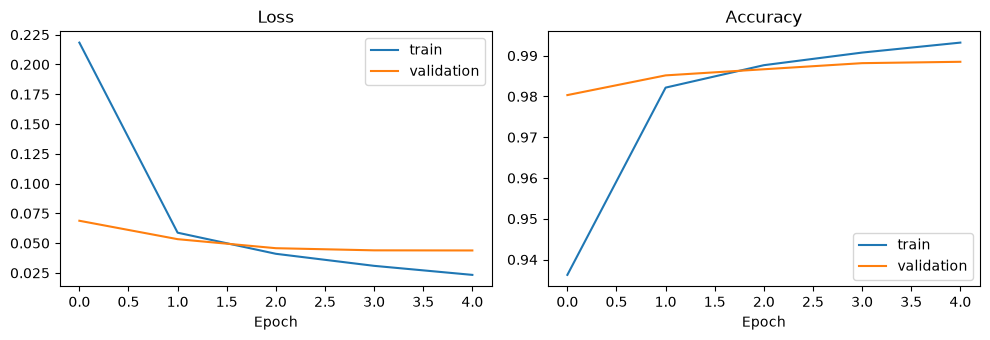

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.show()

## Evaluate on the untouched test set

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.0338
Test accuracy: 0.9897


## Error analysis

Total misclassified images: 103


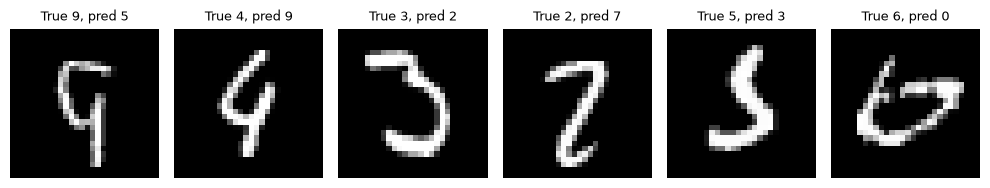

In [11]:
true_label = y_test.argmax(1)
predicted_label = model.predict(X_test, verbose=0).argmax(1)
errors = np.flatnonzero(true_label != predicted_label)
print(f"Total misclassified images: {len(errors)}")

plt.figure(figsize=(10, 2.4))
for i, idx in enumerate(errors[:6]):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_test[idx, :, :, 0], cmap="gray")
    plt.title(f"True {true_label[idx]}, pred {predicted_label[idx]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

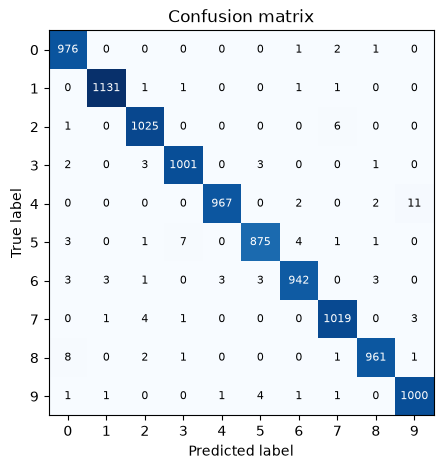

In [12]:
matrix = np.zeros((10, 10), dtype=int)
np.add.at(matrix, (true_label, predicted_label), 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(matrix, cmap="Blues")
for t in range(10):
    for p in range(10):
        ax.text(
            p,
            t,
            matrix[t, p],
            ha="center",
            va="center",
            fontsize=8,
            color="white" if matrix[t, p] > matrix.max() / 2 else "black",
        )
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix")
plt.show()

## Takeaways

- Keeping the image 2-D and sharing filter weights across positions removes a large share of the MLP's
  errors (compare the misclassified count above with notebook 01).
- One run on one seed is an anecdote. The study in this repository trains each model on several seeds,
  tests whether the gap is significant on paired predictions, checks calibration, shifts the test digits
  by a few pixels, and turns accuracy into a decision: how many digits can be read automatically under a
  fixed error budget. See the [README](../README.md).